# CME日経平均先物 曜日別パフォーマンス分析

このノートブックでは、yfinanceを使用してCME（シカゴ・マーカンタイル取引所）に上場している日経225先物のデータを取得し、曜日別のパフォーマンスを分析します。

## 分析項目
1. **曜日別 1日の騰落率 (Close to Close)**
2. **曜日別 オーバーナイト騰落率 (Prev Close to Open)**
3. **曜日別 日中騰落率 (Open to Close)**

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from datetime import datetime

# グラフのスタイル設定
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['Meiryo', 'Yu Gothic', 'Hiragino Maru Gothic Pro', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False

In [8]:
# CME日経225先物 (NIY=F: 円建) のデータを取得
# NKD=F (ドル建) もありますが、ここでは円建を使用します
ticker = "NIY=F"
df = yf.download(ticker, start="2010-01-01")

if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# 曜日の追加
df['day_of_week'] = df.index.dayofweek
df['day_name'] = df.index.day_name()

# 各種リターンの計算
df['ret_daily'] = df['Close'].pct_change() # 前日終値 -> 当日終値
df['ret_overnight'] = (df['Open'] - df['Close'].shift(1)) / df['Close'].shift(1) # 前日終値 -> 当日始値
df['ret_intraday'] = (df['Close'] - df['Open']) / df['Open'] # 当日始値 -> 当日終値

df = df.dropna()

print(f"Ticker: {ticker}")
print(f"Data Period: {df.index.min()} to {df.index.max()}")
print(f"Total Samples: {len(df)}")

[*********************100%***********************]  1 of 1 completed

Ticker: NIY=F
Data Period: 2010-01-05 00:00:00 to 2026-05-03 00:00:00
Total Samples: 4100


## 1. 曜日別パフォーマンス集計

In [9]:
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']

agg_stats = df.groupby('day_name').agg({
    'ret_daily': ['mean', lambda x: (x > 0).mean()],
    'ret_overnight': ['mean', lambda x: (x > 0).mean()],
    'ret_intraday': ['mean', lambda x: (x > 0).mean()]
}).reindex(weekday_order)

agg_stats.columns = [
    '1日リターン平均', '1日上昇確率',
    'オーバーナイト平均', 'オーバーナイト上昇確率',
    '日中平均', '日中上昇確率'
]

display(agg_stats.style.format("{:.3%}"))

,1日リターン平均,1日上昇確率,オーバーナイト平均,オーバーナイト上昇確率,日中平均,日中上昇確率
day_name,,,,,,
Monday,0.041%,54.047%,0.011%,50.914%,0.030%,20.235%
Tuesday,0.097%,52.781%,0.080%,51.834%,0.017%,18.817%
Wednesday,0.104%,53.325%,0.060%,51.069%,0.044%,20.903%
Thursday,-0.017%,47.101%,0.031%,47.705%,-0.048%,16.908%
Friday,0.027%,53.178%,-0.028%,47.677%,0.055%,22.738%


## 2. 可視化

C:\Users\user\AppData\Local\Temp\ipykernel_39908\1098796820.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=agg_stats.index, y=agg_stats[col].astype(float), ax=axes[i], palette=palette)
C:\Users\user\AppData\Local\Temp\ipykernel_39908\1098796820.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=agg_stats.index, y=agg_stats[col].astype(float), ax=axes[i], palette=palette)
C:\Users\user\AppData\Local\Temp\ipykernel_39908\1098796820.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=agg_stats.index, y=agg_stats[col].astype(float

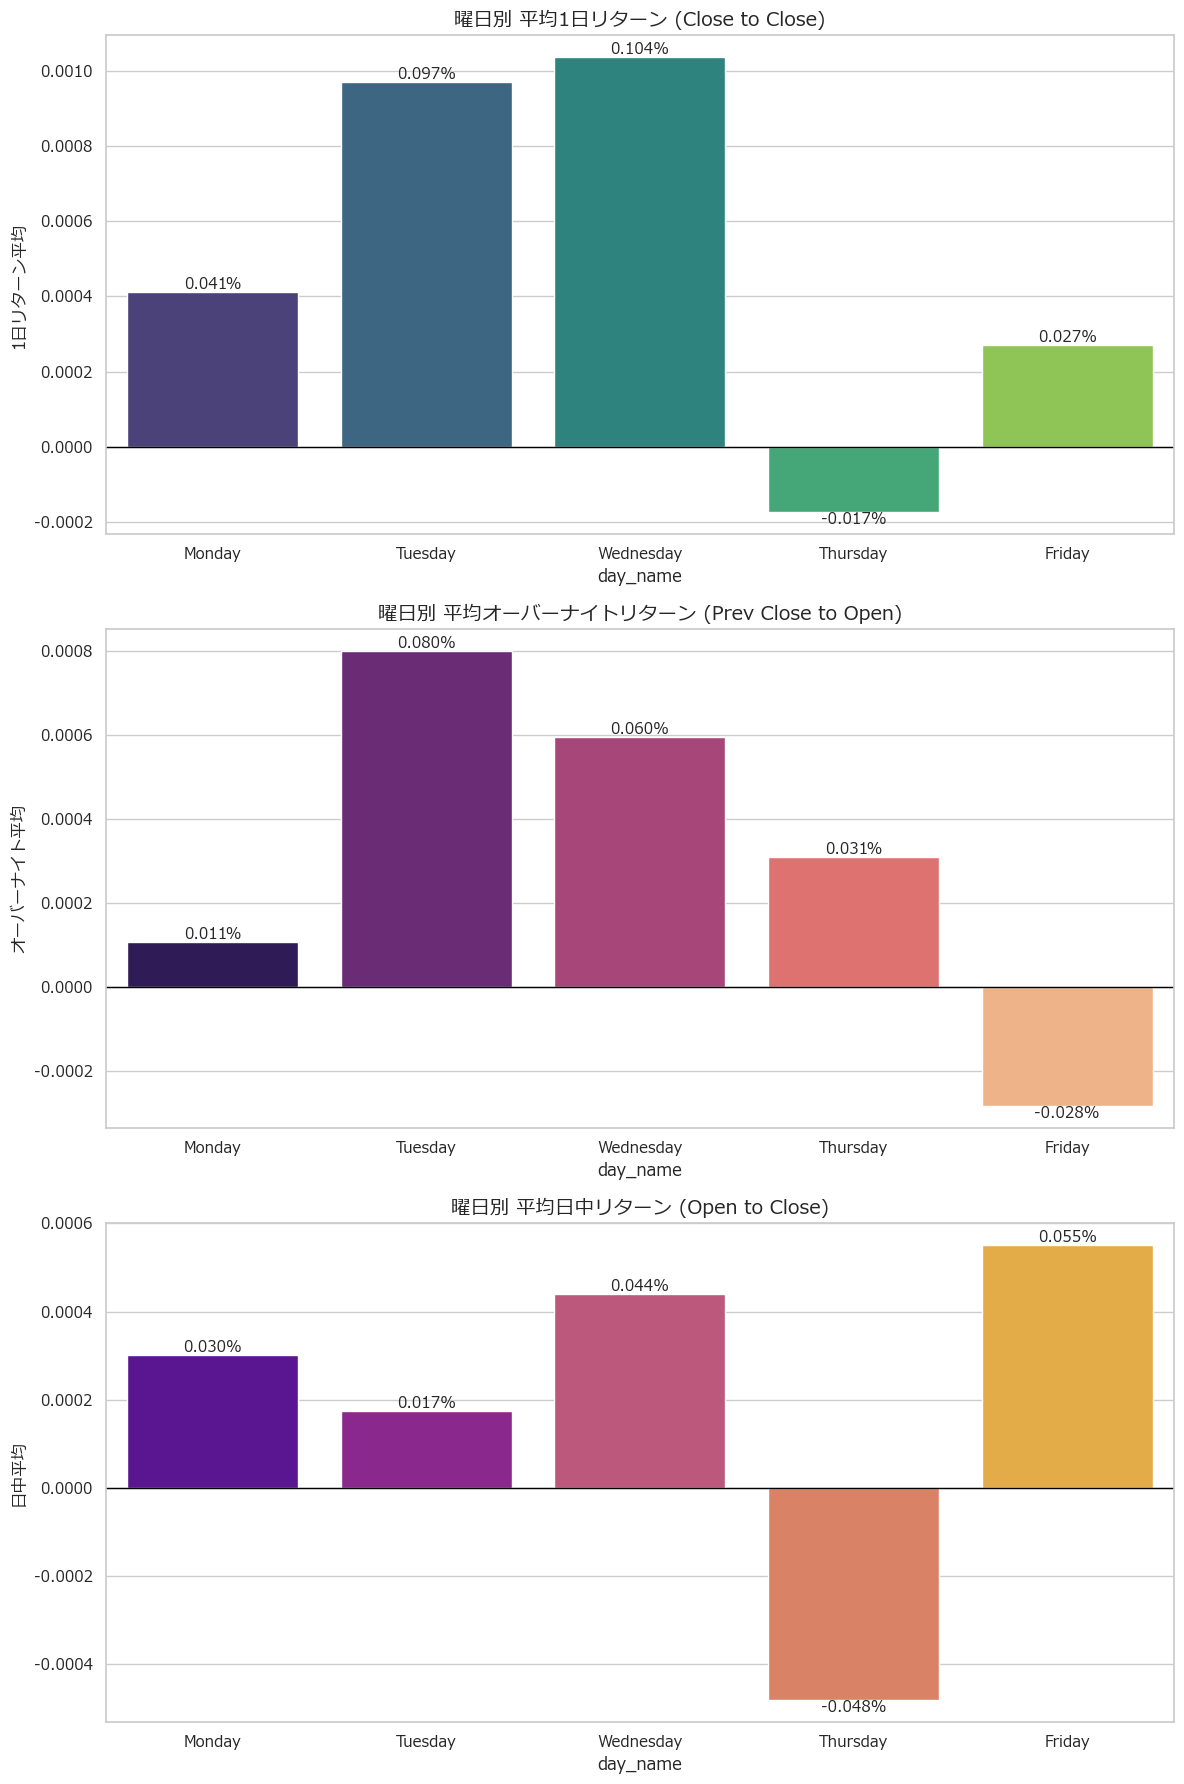

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(12, 18))

metrics = [
    ('1日リターン平均', '曜日別 平均1日リターン (Close to Close)', 'viridis'),
    ('オーバーナイト平均', '曜日別 平均オーバーナイトリターン (Prev Close to Open)', 'magma'),
    ('日中平均', '曜日別 平均日中リターン (Open to Close)', 'plasma')
]

for i, (col, title, palette) in enumerate(metrics):
    sns.barplot(x=agg_stats.index, y=agg_stats[col].astype(float), ax=axes[i], palette=palette)
    axes[i].set_title(title, fontsize=14)
    axes[i].axhline(0, color='black', lw=1)
    for p in axes[i].patches:
        axes[i].annotate(f'{p.get_height():.3%}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='bottom' if p.get_height() > 0 else 'top', fontsize=11)

plt.tight_layout()
plt.show()

## 3. 累積リターンの比較（曜日別）

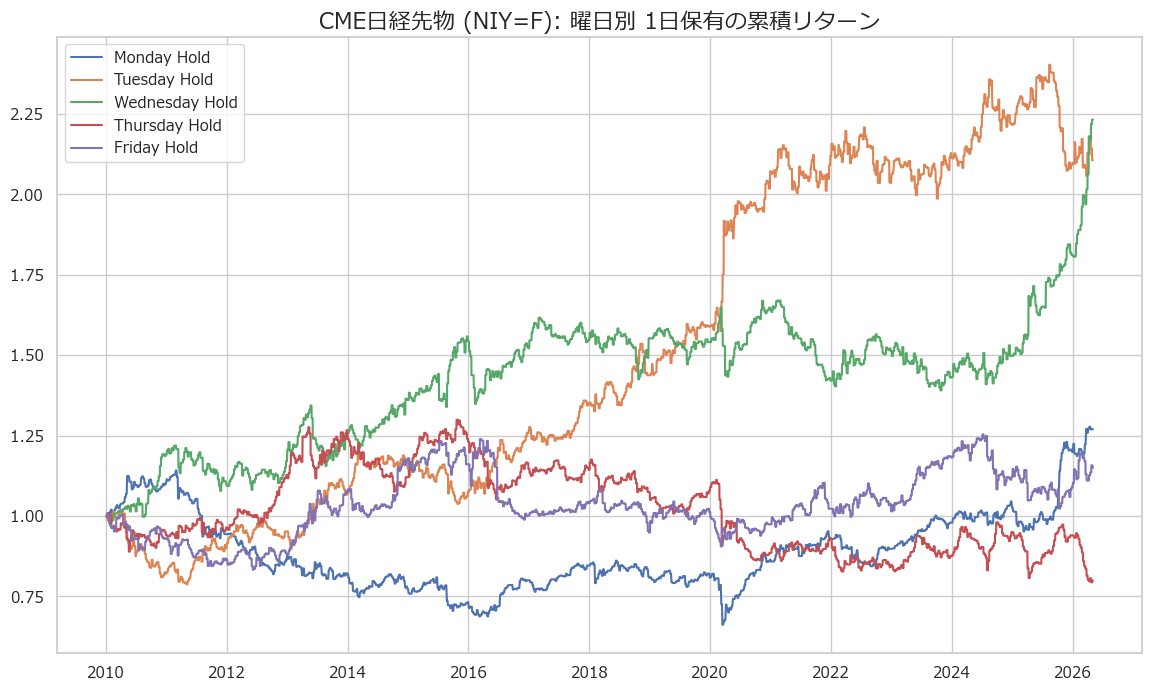

In [11]:
plt.figure(figsize=(14, 8))
for day_name in weekday_order:
    day_ret = np.where(df['day_name'] == day_name, df['ret_daily'], 0)
    cum_ret = (1 + day_ret).cumprod()
    plt.plot(df.index, cum_ret, label=f'{day_name} Hold')

plt.title(f'CME日経先物 ({ticker}): 曜日別 1日保有の累積リターン', fontsize=16)
plt.legend()
plt.show()

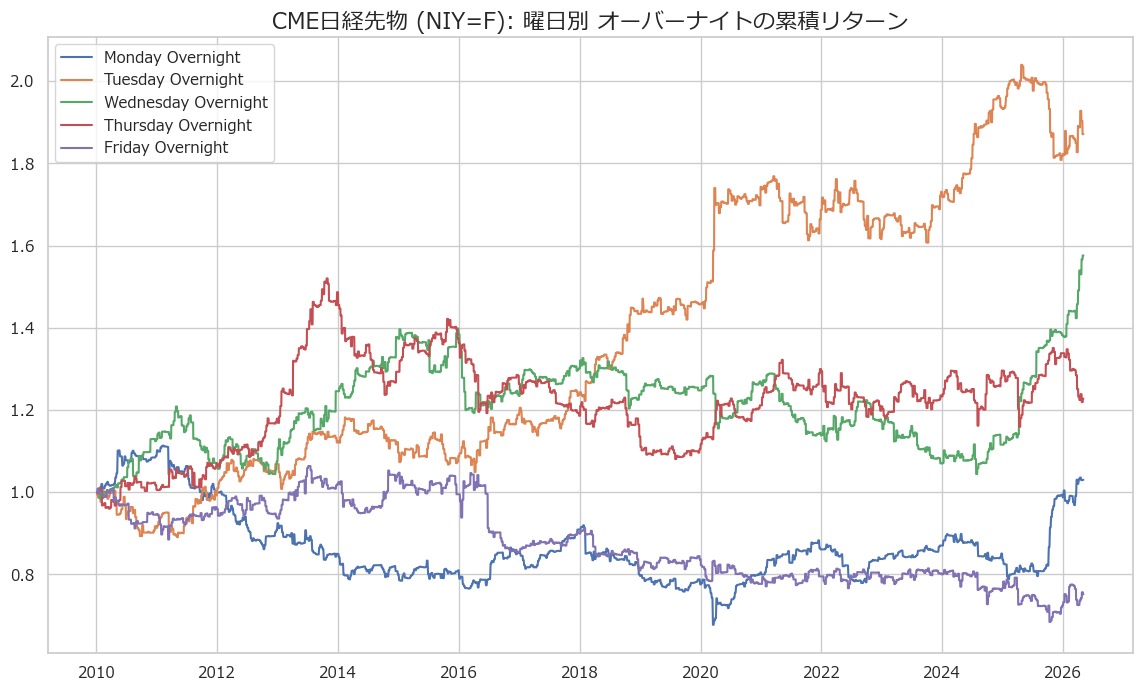

In [12]:
plt.figure(figsize=(14, 8))
for day_name in weekday_order:
    day_ret = np.where(df['day_name'] == day_name, df['ret_overnight'], 0)
    cum_ret = (1 + day_ret).cumprod()
    plt.plot(df.index, cum_ret, label=f'{day_name} Overnight')

plt.title(f'CME日経先物 ({ticker}): 曜日別 オーバーナイトの累積リターン', fontsize=16)
plt.legend()
plt.show()

## 考察

CME日経先物においても、月曜日（あるいは特定の曜日）に顕著なアノマリーがあるかを確認してください。
先物市場は24時間近いため、現物ETF（1579.Tなど）の結果とはリターンの分配が異なる可能性があります。